## Task 1 - Data Preparation

In [ ]:
pip install torch torchvision

In [1]:
import pandas as pd
import numpy as np
import os
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

df = pd.read_csv('data.csv')

df = df[['Filename', 'AQI_Class']] 

label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['AQI_Class'])
num_classes = len(label_encoder.classes_)
print(f"Classes found: {label_encoder.classes_}")

train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['label'])
print(f"Splits -> Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

class AQIDataset(Dataset):
    def __init__(self, dataframe, img_dir, img_col, transform=None):
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.img_col = img_col
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = str(self.dataframe.iloc[idx][self.img_col])
        img_path = os.path.join(self.img_dir, img_name)
        
        label = self.dataframe.iloc[idx]['label']
        
        try:
            image = Image.open(img_path).convert("RGB")
        except FileNotFoundError:
            print(f"Warning: Image not found at {img_path}")
            
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.long)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

image_folder = 'sampled_images'

train_dataset = AQIDataset(train_df, img_dir=image_folder, img_col='Filename', transform=transform)
val_dataset = AQIDataset(val_df, img_dir=image_folder, img_col='Filename', transform=transform)
test_dataset = AQIDataset(test_df, img_dir=image_folder, img_col='Filename', transform=transform)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("\nData Preparation Complete! DataLoaders are ready.")

Classes found: ['a_Good' 'b_Moderate' 'c_Unhealthy_for_Sensitive_Groups' 'd_Unhealthy'
 'e_Very_Unhealthy' 'f_Severe']
Splits -> Train: 4200 | Val: 900 | Test: 900

Data Preparation Complete! DataLoaders are ready.


## Task 2 – Basic CNN Model

In [2]:
import torch.nn as nn
import torch.nn.functional as F

class BasicCNN(nn.Module):
    def __init__(self, num_classes):
        super(BasicCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        
        x = x.view(-1, 128 * 28 * 28)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

basic_model = BasicCNN(num_classes=num_classes)
print("Basic CNN Model Architecture Initialized.")

Basic CNN Model Architecture Initialized.


In [3]:
import torch.optim as optim

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
basic_model = basic_model.to(device)

# Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(basic_model.parameters(), lr=0.001)

print(f"Using device: {device}")

Using device: cuda


In [4]:
epochs = 10 # You can adjust this based on how fast it converges
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(epochs):
    # --- Training Phase ---
    basic_model.train()
    train_loss, correct_train, total_train = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()        # Clear old gradients
        outputs = basic_model(images) # Forward pass
        loss = criterion(outputs, labels) # Calculate loss
        loss.backward()              # Backward pass
        optimizer.step()             # Update weights
        
        # Track metrics
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    avg_train_loss = train_loss / len(train_loader)
    train_acc = correct_train / total_train
    
    # --- Validation Phase ---
    basic_model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    
    with torch.no_grad(): # No gradients needed for validation
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = basic_model(images)
            loss = criterion(outputs, labels)
            
            # Track metrics
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    avg_val_loss = val_loss / len(val_loader)
    val_acc = correct_val / total_val
    
    # Save history for Task 5 plotting
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {avg_val_loss:.4f}, Acc: {val_acc:.4f}")

print("\nTraining Complete!")

Epoch [1/10] | Train Loss: 1.5019, Acc: 0.4131 | Val Loss: 1.1805, Acc: 0.5244
Epoch [2/10] | Train Loss: 1.0252, Acc: 0.6086 | Val Loss: 0.8651, Acc: 0.6689
Epoch [3/10] | Train Loss: 0.7149, Acc: 0.7379 | Val Loss: 0.6844, Acc: 0.7222
Epoch [4/10] | Train Loss: 0.5324, Acc: 0.8024 | Val Loss: 0.5240, Acc: 0.8056
Epoch [5/10] | Train Loss: 0.3558, Acc: 0.8724 | Val Loss: 0.4987, Acc: 0.8400
Epoch [6/10] | Train Loss: 0.2575, Acc: 0.9086 | Val Loss: 0.5276, Acc: 0.8300
Epoch [7/10] | Train Loss: 0.2041, Acc: 0.9290 | Val Loss: 0.5630, Acc: 0.8256
Epoch [8/10] | Train Loss: 0.1579, Acc: 0.9440 | Val Loss: 0.5106, Acc: 0.8533
Epoch [9/10] | Train Loss: 0.1328, Acc: 0.9538 | Val Loss: 0.5618, Acc: 0.8478
Epoch [10/10] | Train Loss: 0.0986, Acc: 0.9667 | Val Loss: 0.6072, Acc: 0.8511

Training Complete!


## Task 3 – Pretrained CNN Model (Transfer Learning)

In [5]:
import torchvision.models as models
import torch.nn as nn

resnet_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in resnet_model.parameters():
    param.requires_grad = False

num_ftrs = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_ftrs, num_classes)

resnet_model = resnet_model.to(device)
print("Pretrained ResNet-18 Model Initialized with modified classification layer.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/heer/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%


Pretrained ResNet-18 Model Initialized with modified classification layer.


In [11]:
import torch.optim as optim
import torch.nn as nn
import torch

# 1. Unfreeze ALL layers so the entire network can learn the AQI features
for param in resnet_model.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()

# 2. Update the optimizer to train ALL parameters, using a lower learning rate
optimizer_resnet = optim.Adam(resnet_model.parameters(), lr=0.0001) 

resnet_epochs = 10
resnet_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("Starting Transfer Learning (Fine-Tuning) Training...")
for epoch in range(resnet_epochs):
    resnet_model.train()
    train_loss, correct_train, total_train = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer_resnet.zero_grad()
        outputs = resnet_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_resnet.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    avg_train_loss = train_loss / len(train_loader)
    train_acc = correct_train / total_train
    
    resnet_model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet_model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    avg_val_loss = val_loss / len(val_loader)
    val_acc = correct_val / total_val
    
    resnet_history['train_loss'].append(avg_train_loss)
    resnet_history['val_loss'].append(avg_val_loss)
    resnet_history['train_acc'].append(train_acc)
    resnet_history['val_acc'].append(val_acc)
    
    print(f"Epoch [{epoch+1}/{resnet_epochs}] | Train Loss: {avg_train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {avg_val_loss:.4f}, Acc: {val_acc:.4f}")

print("\nFine-Tuning Complete!")

Starting Transfer Learning (Fine-Tuning) Training...
Epoch [1/10] | Train Loss: 0.3202, Acc: 0.8869 | Val Loss: 0.1972, Acc: 0.9400
Epoch [2/10] | Train Loss: 0.0645, Acc: 0.9814 | Val Loss: 0.1387, Acc: 0.9656
Epoch [3/10] | Train Loss: 0.0258, Acc: 0.9938 | Val Loss: 0.1819, Acc: 0.9667
Epoch [4/10] | Train Loss: 0.0196, Acc: 0.9955 | Val Loss: 0.1114, Acc: 0.9778
Epoch [5/10] | Train Loss: 0.0053, Acc: 0.9988 | Val Loss: 0.1272, Acc: 0.9644
Epoch [6/10] | Train Loss: 0.0261, Acc: 0.9924 | Val Loss: 0.1779, Acc: 0.9600
Epoch [7/10] | Train Loss: 0.1073, Acc: 0.9676 | Val Loss: 0.1908, Acc: 0.9444
Epoch [8/10] | Train Loss: 0.0685, Acc: 0.9786 | Val Loss: 0.1365, Acc: 0.9711
Epoch [9/10] | Train Loss: 0.0177, Acc: 0.9948 | Val Loss: 0.1414, Acc: 0.9767
Epoch [10/10] | Train Loss: 0.0046, Acc: 0.9986 | Val Loss: 0.0925, Acc: 0.9778

Fine-Tuning Complete!


## Task 4 – Model Training and Evaluation

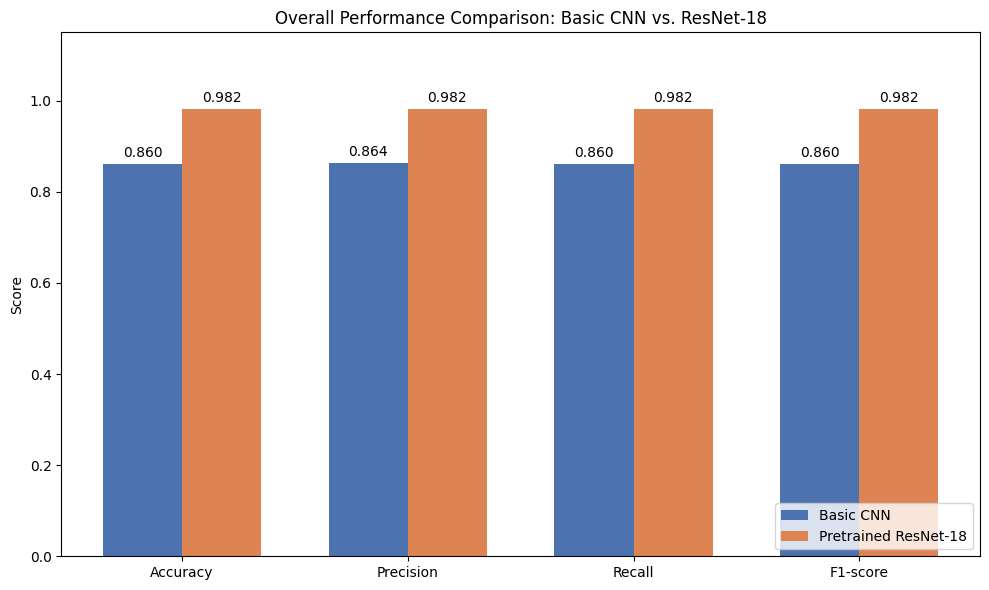

In [18]:
import numpy as np

metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1-score']
basic_scores = list(basic_metrics)
resnet_scores = list(resnet_metrics)

x = np.arange(len(metrics_labels)) 
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, basic_scores, width, label='Basic CNN', color='#4C72B0')
rects2 = ax.bar(x + width/2, resnet_scores, width, label='Pretrained ResNet-18', color='#DD8452')

ax.set_ylabel('Score')
ax.set_title('Overall Performance Comparison: Basic CNN vs. ResNet-18')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.legend(loc='lower right')

ax.set_ylim(0, 1.15)

ax.bar_label(rects1, padding=3, fmt='%.3f')
ax.bar_label(rects2, padding=3, fmt='%.3f')

plt.tight_layout()
plt.show()

## Task 5 – Training Curves

Generating curves for Basic CNN...


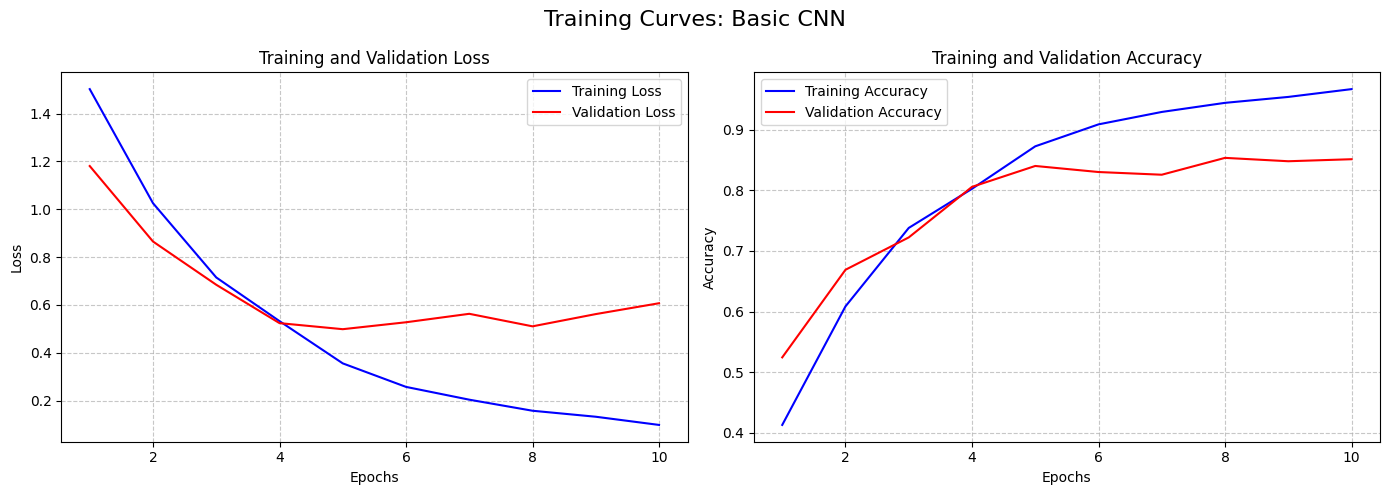

Generating curves for Pretrained ResNet-18...


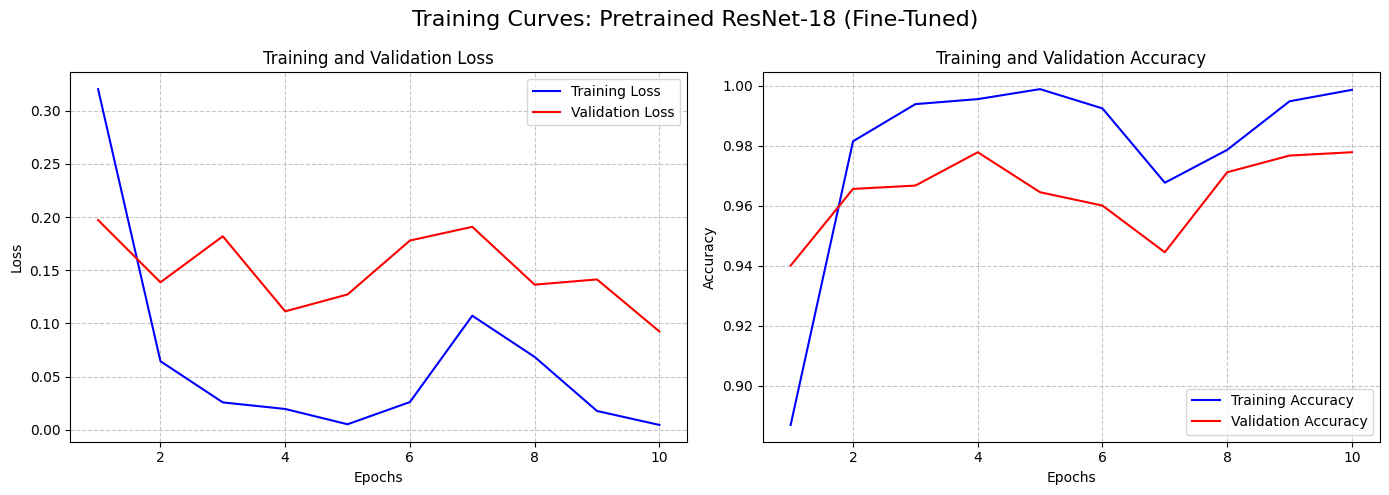

In [15]:
import matplotlib.pyplot as plt

def plot_training_curves(history, model_name):
    epochs = range(1, len(history['train_loss']) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Training Curves: {model_name}', fontsize=16)
    
    # Plot 1: Loss
    ax1.plot(epochs, history['train_loss'], 'b-', label='Training Loss')
    ax1.plot(epochs, history['val_loss'], 'r-', label='Validation Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Plot 2: Accuracy
    ax2.plot(epochs, history['train_acc'], 'b-', label='Training Accuracy')
    ax2.plot(epochs, history['val_acc'], 'r-', label='Validation Accuracy')
    ax2.set_title('Training and Validation Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# 1. Plot curves for Basic CNN
print("Generating curves for Basic CNN...")
plot_training_curves(history, "Basic CNN")

# 2. Plot curves for Pretrained ResNet
print("Generating curves for Pretrained ResNet-18...")
plot_training_curves(resnet_history, "Pretrained ResNet-18 (Fine-Tuned)")

Pretrained models typically outperform models trained from scratch because they have already learned to recognize complex shapes, colors, and textures from millions of images. A basic CNN must learn all these foundational visual rules from zero, relying solely on the limited samples within this dataset. Initially, transfer learning with frozen layers struggled because the model attempted to detect specific objects rather than overall environmental markers like haze. However, by fine-tuning the entire network, the model successfully adapted its extensive visual knowledge to accurately classify the AQI categories. Ultimately, transfer learning significantly aided the pretrained model in understanding complex image features much better than the basic model could.

## Task 6 – Misclassification Analysis

Extracting and visualizing misclassified images...


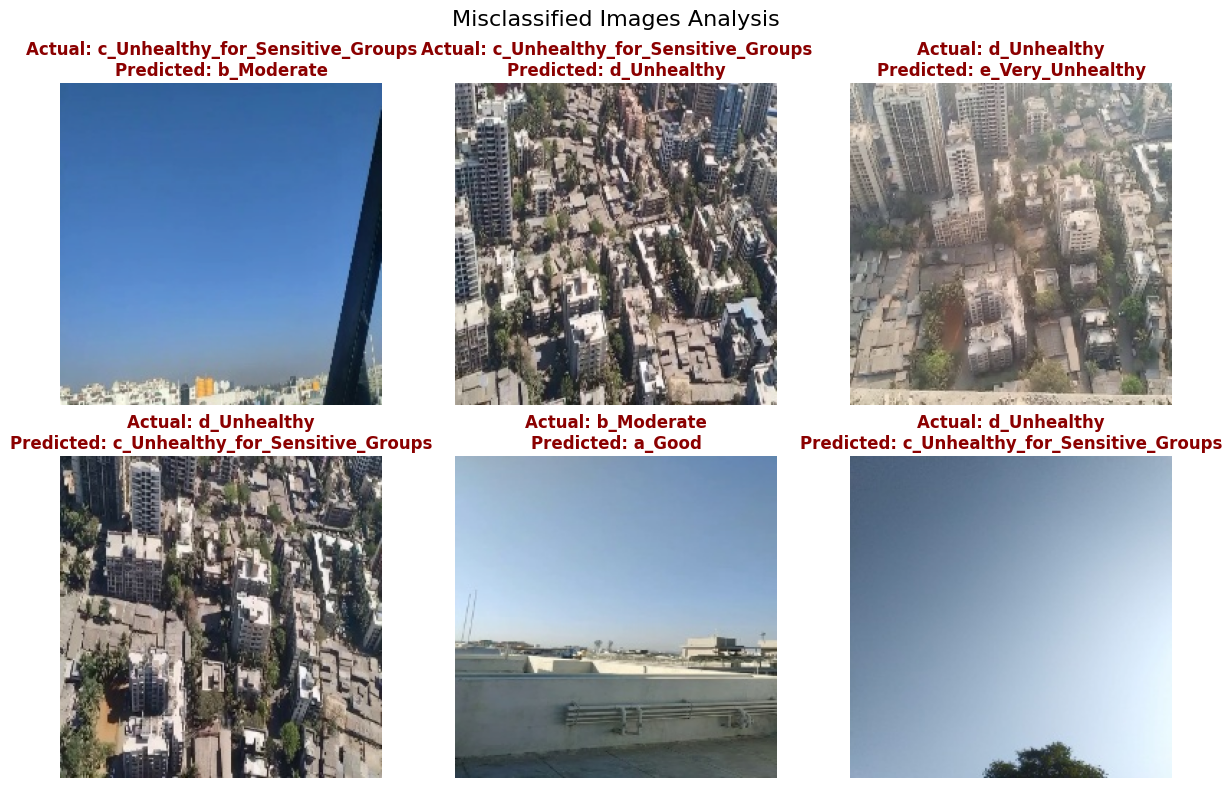

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_misclassifications(model, test_loader, device, class_names, num_images=6):
    model.eval()
    misclassified_imgs = []
    misclassified_trues = []
    misclassified_preds = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            for i in range(len(preds)):
                if preds[i] != labels[i]:
                    misclassified_imgs.append(images[i].cpu())
                    misclassified_trues.append(labels[i].cpu().item())
                    misclassified_preds.append(preds[i].cpu().item())
                    
                    if len(misclassified_imgs) >= num_images:
                        break
            if len(misclassified_imgs) >= num_images:
                break

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    fig.suptitle('Misclassified Images Analysis', fontsize=16)
    axes = axes.flatten()
    
    for idx in range(num_images):
        img = misclassified_imgs[idx]
        
        img = img.numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        axes[idx].imshow(img)
        true_label = class_names[misclassified_trues[idx]]
        pred_label = class_names[misclassified_preds[idx]]
        
        axes[idx].set_title(f"Actual: {true_label}\nPredicted: {pred_label}", color='darkred', fontweight='bold')
        axes[idx].axis('off')
        
    plt.tight_layout()
    plt.show()

print("Extracting and visualizing misclassified images...")
visualize_misclassifications(resnet_model, test_loader, device, class_names, num_images=6)